# Datavalidation

The Data has been created for 14.400 Buildings via a highly customized version of [TSIB](https://github.com/NV717/tsorb_simuflex). Before any further proceedings the validity of the generated data itself and its distribution is checked.

## ToDo

1. Check all runs completed/ which failed
2. Check generated results have same parameters as manifest and distribution
3. check timeseries for missing values/negative values/ problems and if distribution makes sense
4. check for identical timeseries

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
import ast
from itertools import chain
from collections import Counter
from DataPreparationHelper import *
from tqdm import tqdm

RESULTS_DIR = Path(r"Generation\Generation")
test_path = r"Generation/Generation/run_000013.h5"
MANIFEST_PATH = r"C:\Users\Samuel\FH_Aachen\MasterThesis\Master_Thesis_EWI_2026\DataPreparation\Generation\manifest.parquet"

In [2]:
manifest = pd.read_parquet(MANIFEST_PATH)
manifest = manifest.iloc[:361]

In [3]:
completed_runs = RESULTS_DIR.glob("run_*.h5")
dfs = [pd.read_hdf(run, key="params") for run in completed_runs]
realised_manifest = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [4]:
realised_manifest_cut = pd.concat([realised_manifest.iloc[:56], realised_manifest.iloc[60:341], realised_manifest.iloc[342:]])

Planned: 361
Realized: 356
Missing Cols: 5
Index([56, 57, 58, 59, 341], dtype='int64')
Planned and Realized Values are identical: True
Planned and Realized Differences: Empty DataFrame
Columns: []
Index: []
overview planned================================================================================
Overview
Rows: 356
Unique buildings: 119
Unique runs: 356
MISSING VALUES
country            0
buildingType       0
surrounding        0
buildingAgeBin     0
a_ref              0
n_apartments       0
year_type          0
future             0
climateRegion      0
n_persons          0
freq               0
hasFirePlace       0
varyoccupancy      0
mean_load          0
nightReduction     0
capControl         0
occControl         0
comfortT_lb        0
comfortT_ub        0
cores              0
useCache           0
building_id        0
run_id             0
seed               0
n_persons_sum      0
area_per_person    0
dtype: int64
DISTRIBUTION: buildingType
              count  percent
building

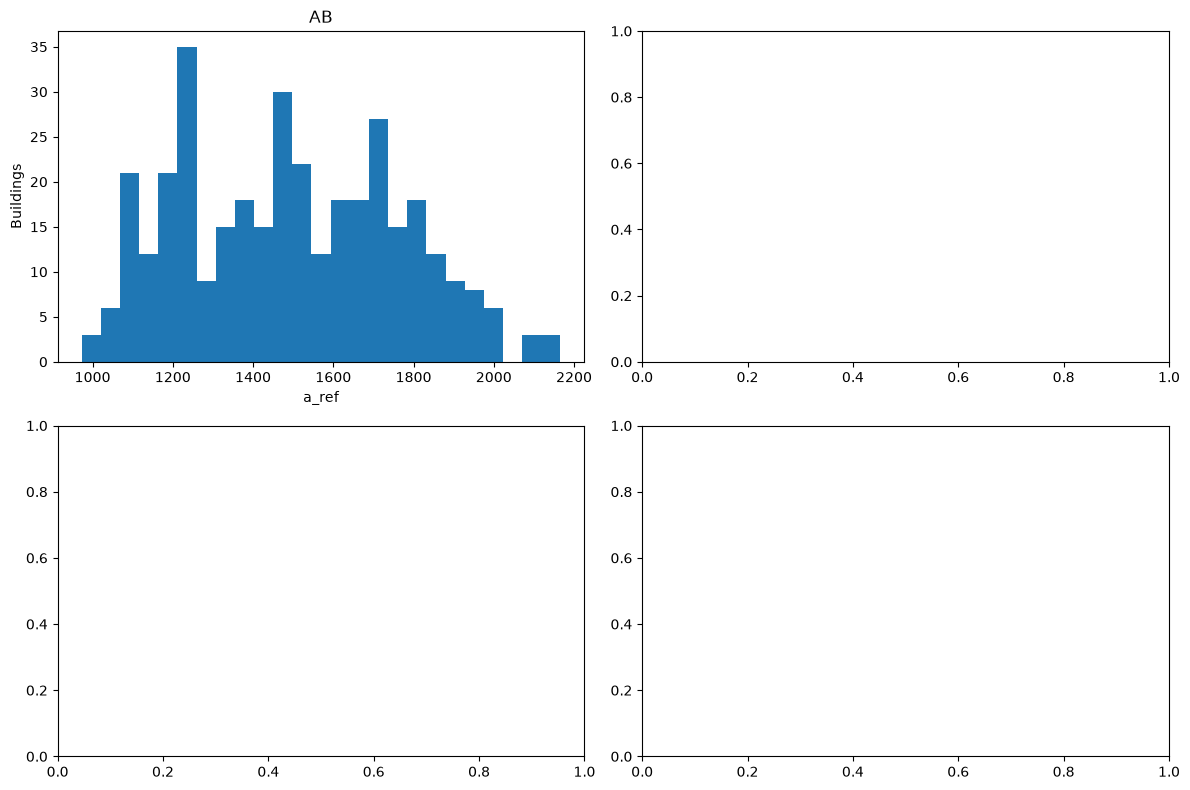

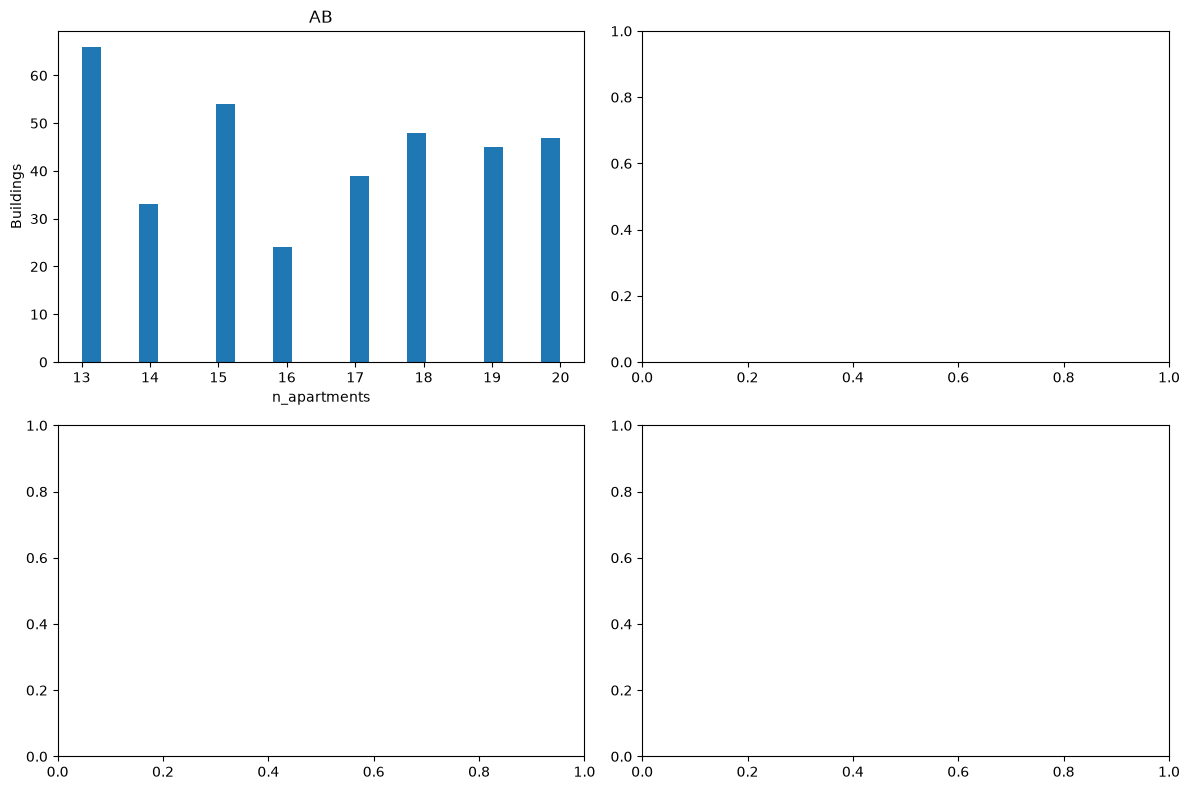

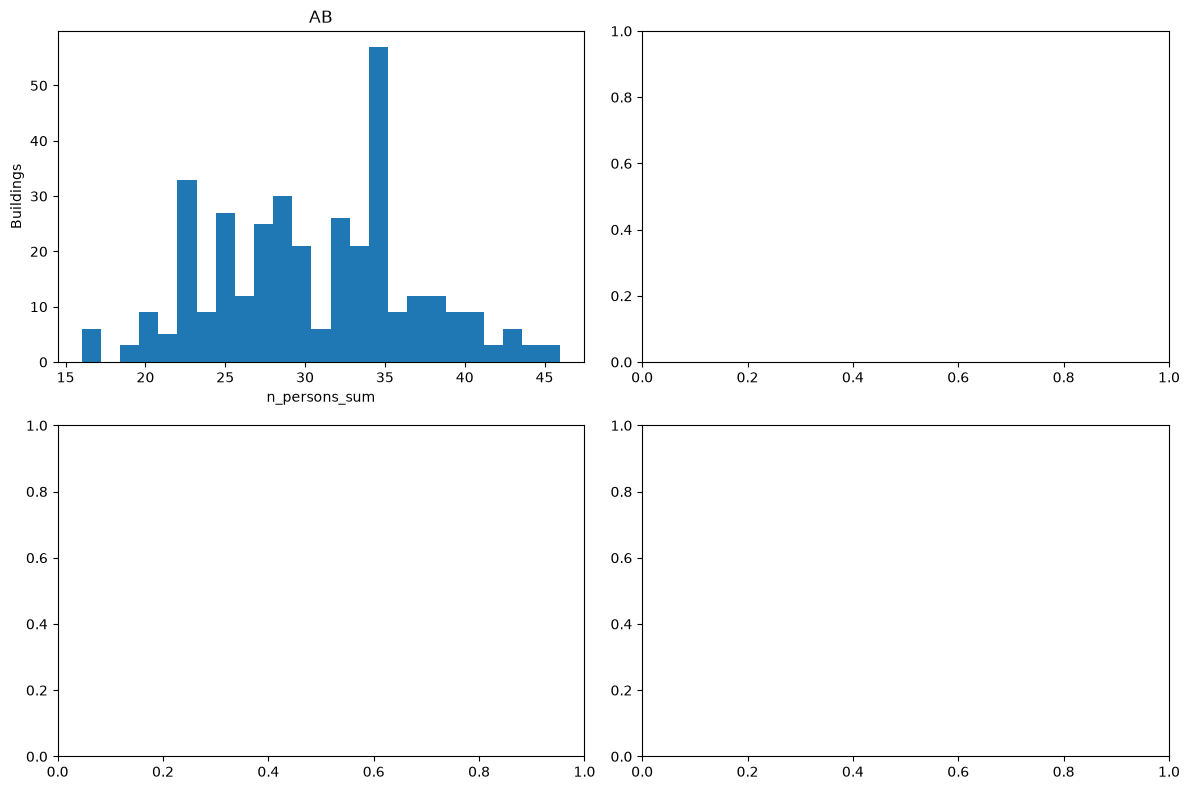

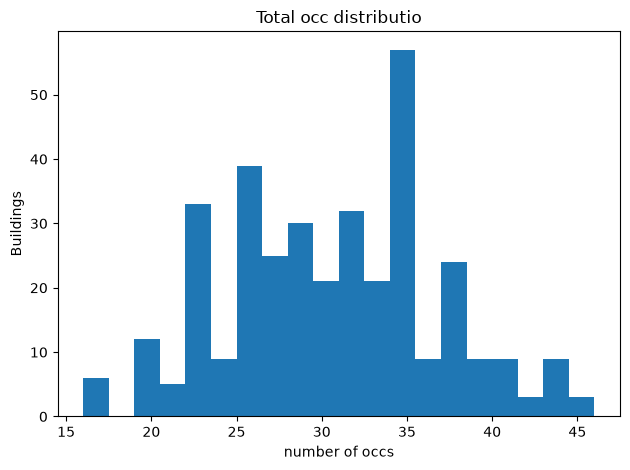

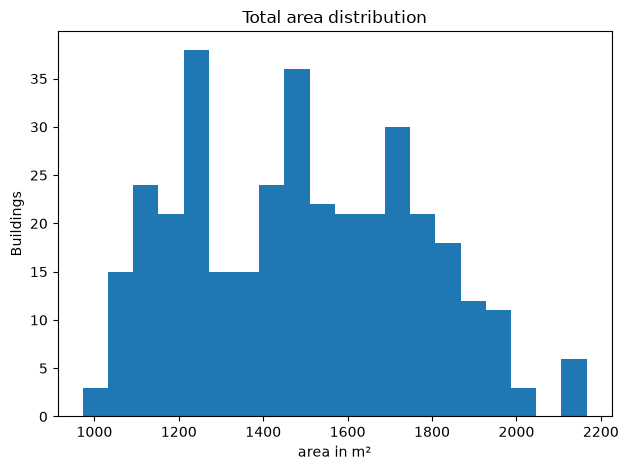

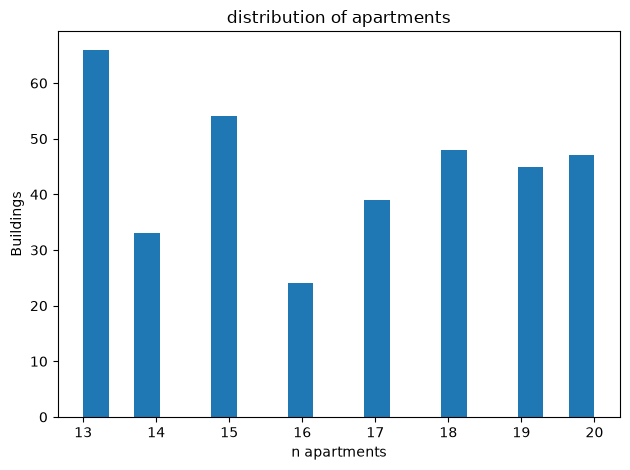

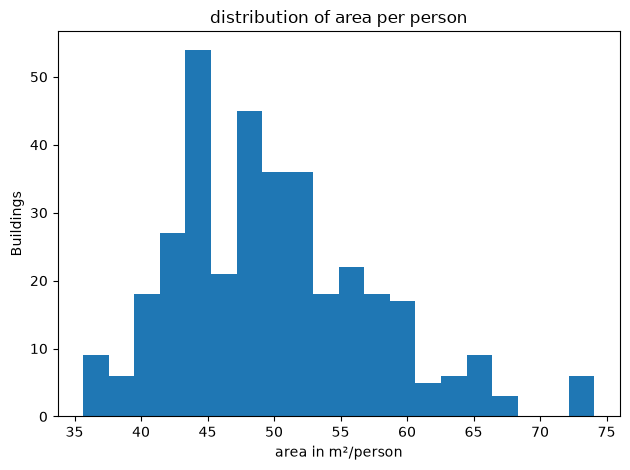

overview realized================================================================================
Overview
Rows: 356
Unique buildings: 119
Unique runs: 356
MISSING VALUES
country                   0
buildingType              0
surrounding               0
buildingAgeBin            0
a_ref                     0
n_apartments              0
year_type                 0
future                    0
climateRegion             0
n_persons                 0
freq                      0
hasFirePlace              0
varyoccupancy             0
mean_load                 0
nightReduction            0
capControl                0
occControl                0
comfortT_lb               0
comfortT_ub               0
cores                     0
useCache                  0
seed                      0
weatherFilepath           0
weatherID                 0
resolved_climateRegion    0
resolved_latitude         0
resolved_longitude        0
state_seed                0
apartment_seeds           0
maxLoadViolation_

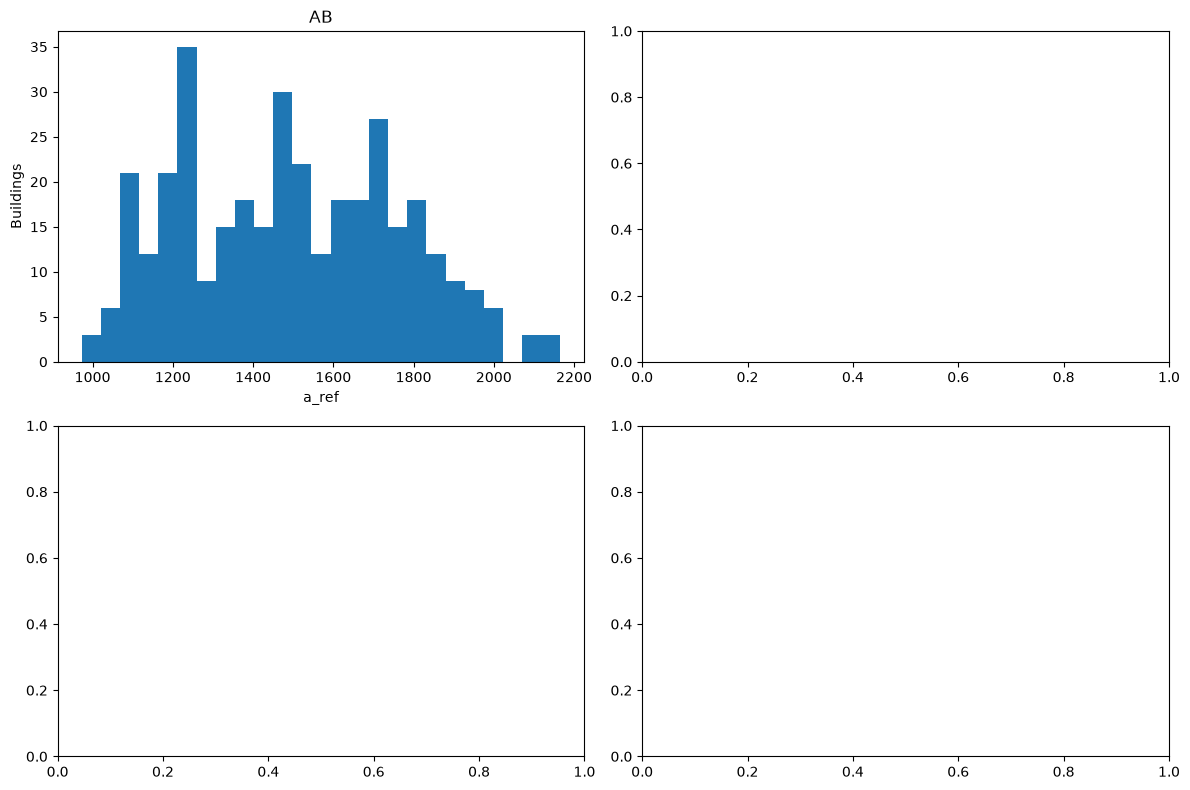

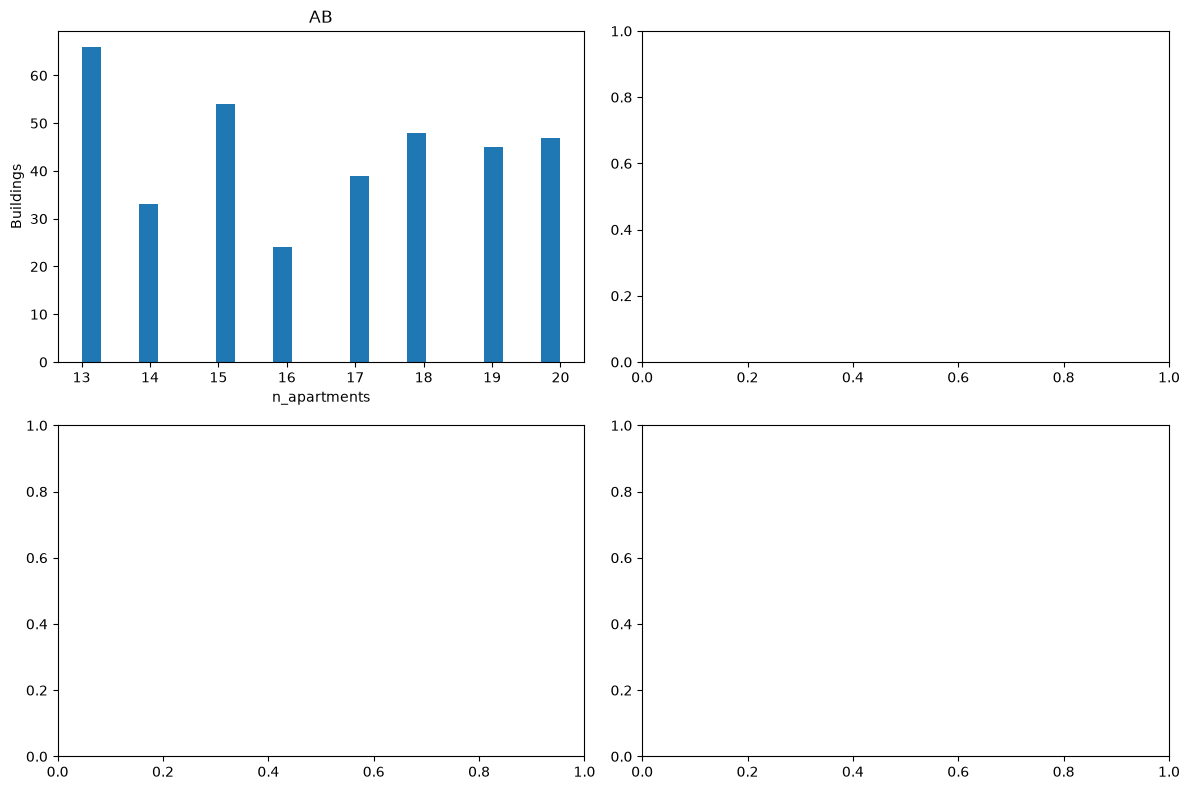

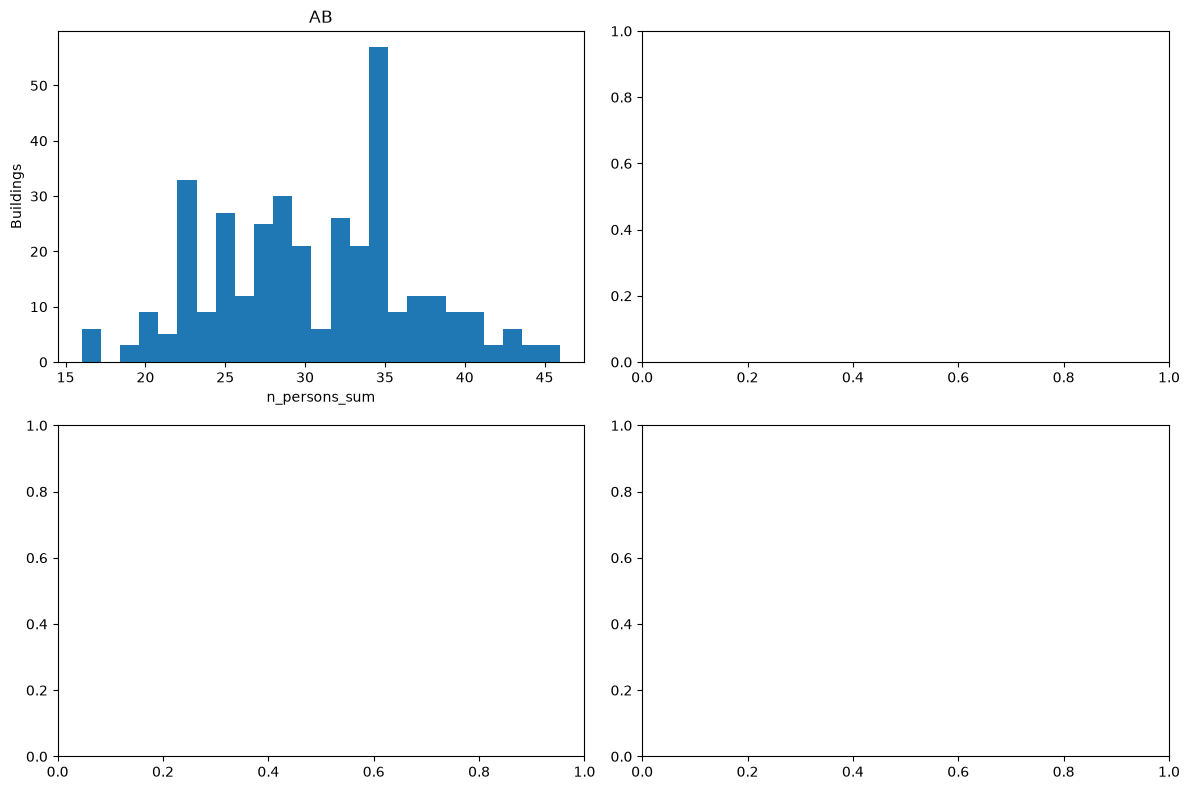

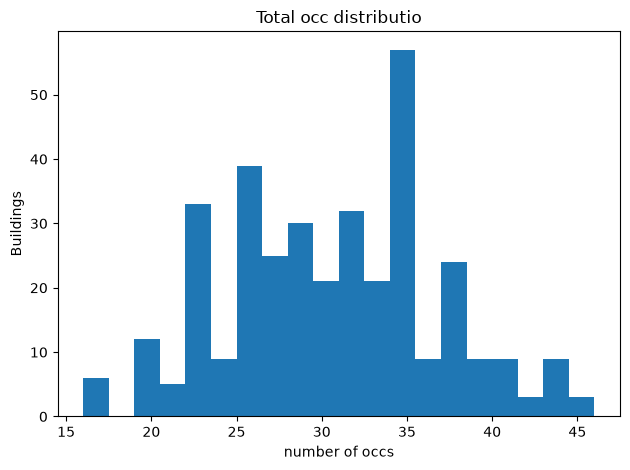

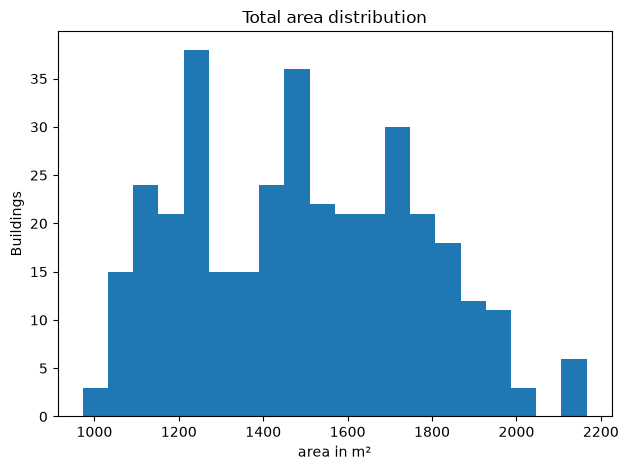

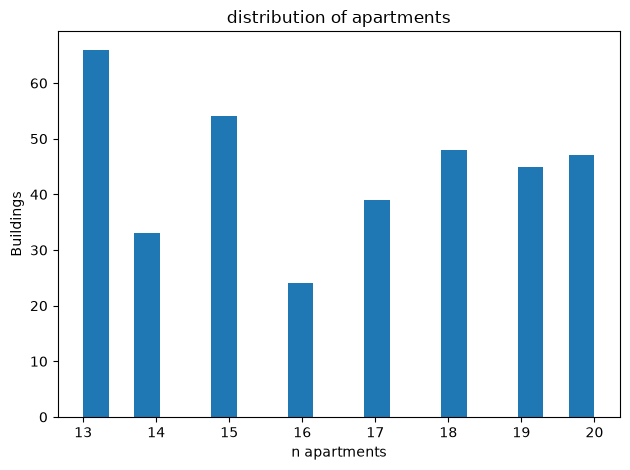

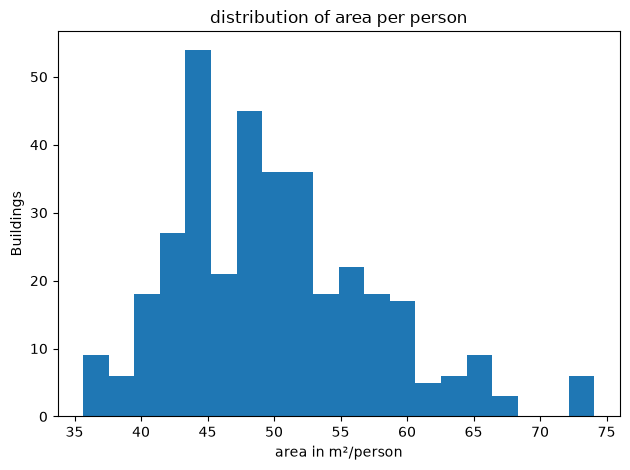

year_type  future  weatherID                                  
average    False   TRY2015_1_average_TRY2015_544834090831_Jahr    0.333333
                   TRY2015_1_average_TRY2015_536468076300_Jahr    0.333333
                   TRY2015_1_average_TRY2015_535407086034_Jahr    0.333333
           True    TRY2045_1_average_TRY2045_535293084322_Jahr    0.333333
                   TRY2045_1_average_TRY2045_536599098044_Jahr    0.333333
                   TRY2045_1_average_TRY2045_535407086034_Jahr    0.333333
cold       True    TRY2045_1_cold_TRY2045_539647092989_Wint       0.333333
                   TRY2045_1_cold_TRY2045_546561086632_Wint       0.166667
                   TRY2045_1_cold_TRY2045_533679071939_Wint       0.166667
                   TRY2045_1_cold_TRY2045_544834090831_Wint       0.166667
                   TRY2045_1_cold_TRY2045_537123072032_Wint       0.166667
hot        False   TRY2015_1_hot_TRY2015_539997089829_Somm        0.166667
                   TRY2015_1_hot_TRY2

In [5]:
comp_manifests(manifest,realised_manifest_cut)

In [6]:
check_duplicate_timeseries(realised_manifest)

Duplicated Seed Lists: False
Duplicated Seeds: <StringArray>
[]
Length: 0, dtype: str


In [7]:
ts_res = check_timeseries(RESULTS_DIR)

Checking timeseries: 100%|██████████| 361/361 [00:42<00:00,  8.47run/s]


,run_id,nan_vals,neg_load_vals,total_persons,a_ref,elec_sum_yearly,elec_sum_yearly_per_occ,elec_sum_yearly_per_a_ref,elec_max,elec_min,...,temperature_p05,temperature_p95,buildingType,buildingAgeBin,surrounding,climateRegion,year_type,future,seed,state_seed
0,run_000000,False,False,30,1234.5,38877.468750,1295.915649,31.492481,25.539263,0.577145,...,-6.153333,25.660000,AB,DE.02,Terraced,4,cold,False,1000000,1000000
1,run_000001,False,False,30,1234.5,38269.425781,1275.647583,30.999939,24.303375,0.597164,...,-5.700000,24.030001,AB,DE.02,Terraced,4,cold,False,1000001,1000001
2,run_000002,False,False,30,1234.5,42832.386719,1427.746216,34.696140,27.820505,0.626575,...,-5.826667,24.000000,AB,DE.02,Terraced,4,cold,False,1000002,1000002
3,run_000003,False,False,36,1722.3,52856.445312,1468.234619,30.689453,32.851784,0.844132,...,0.290000,26.740000,AB,DE.02,Terraced,12,hot,True,1000003,1000003
4,run_000004,False,False,36,1722.3,53473.601562,1485.377808,31.047785,25.817797,0.839238,...,0.550000,26.875083,AB,DE.02,Terraced,12,hot,True,1000004,1000004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
356,run_000356,False,False,24,1033.9,40607.527344,1691.980347,39.276066,23.501009,0.578108,...,-0.645000,22.420000,AB,DE.02,Terraced,5,cold,True,1000356,1000356
357,run_000357,False,False,35,1247.8,49335.691406,1409.591187,39.538139,29.343933,0.725698,...,-6.580000,20.400000,AB,DE.02,Terraced,14,cold,False,1000357,1000357
358,run_000358,False,False,35,1247.8,51658.960938,1475.970337,41.400032,31.788359,0.763830,...,-5.410000,22.754999,AB,DE.02,Terraced,14,cold,False,1000358,1000358
359,run_000359,False,False,35,1247.8,48158.031250,1375.943726,38.594349,30.596956,0.740137,...,-6.575000,21.366667,AB,DE.02,Terraced,14,cold,False,1000359,1000359


In [8]:
ts_res


NameError: name 'ts_res' is not defined

In [ ]:
ts_res.to_parquet(
    RESULTS_DIR / "timeseries_summary.parquet",
    index=False,
)